# Model 1: LSTM Embedding Extraction (Numerical Features)

This notebook extracts **LSTM embeddings** from OHLCV price sequences:
- **Input**: 60-day window of scaled OHLCV features
- **Output**: 64-dimensional embedding vector per sample

**Purpose**: The embeddings capture temporal patterns in price data. These will be combined with sentiment features in a separate DNN to predict volatility.

**Key design decisions:**
- LSTM only (no Dense layer) — we want the raw embedding vectors
- Volatility is computed in `volatility_utils.py` for consistency
- Time-based train/test split (no shuffling)

**Output files:**
- `lstm_embeddings.csv` — Embeddings with dates and volatility
- `daily_volatility.csv` — Daily volatility series

---


In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Shared utility for computing daily volatility
from volatility_utils import compute_daily_volatility
!pip install tensorflow

In [2]:
# --- Load raw prices and compute / attach daily volatility ---
# NOTE: Volatility is computed in the shared volatility_utils.py module.
# The daily_volatility.csv file is exported and reused by the sentiment notebook
# to create the final merged dataset (daily_features_for_dnn.csv).

prices = pd.read_csv("price_data_raw.csv")
prices["Date"] = pd.to_datetime(prices["Date"])
prices = prices.sort_values("Date").reset_index(drop=True)

# Filter from 2016 onward to be consistent with sentiment data date range
prices = prices[prices["Date"] >= pd.to_datetime("2016-01-01")].copy()

# OHLCV features for the LSTM input
feature_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
prices = prices.set_index("Date")[feature_cols]

# Compute daily volatility (21-day rolling window of log return std)
# This also saves daily_volatility.csv for use by the sentiment notebook.
vol_df = compute_daily_volatility(
    "price_data_raw.csv",
    start_date="2016-01-01",
    save_path="daily_volatility.csv",
    window=21  # ~1 month of trading days
)
vol_df["date"] = pd.to_datetime(vol_df["date"])
vol_df = vol_df.set_index("date")

# Align prices and volatility on the same calendar dates
data = prices.join(vol_df["volatility"], how="inner")
data.index.name = "Date"

print("Data shape after merge (features + volatility):", data.shape)
print(f"Date range: {data.index.min()} to {data.index.max()}")
print(data.head())



Data shape after merge (features + volatility): (2014, 7)
Date range: 2016-02-03 00:00:00 to 2024-02-02 00:00:00
                 Open       High        Low      Close  Adj Close    Volume  \
Date                                                                          
2016-02-03  16.965179  18.190710  16.460550  18.142651  17.586411  14141365   
2016-02-04  18.358919  20.305349  18.334890  19.968929  19.356695  22386517   
2016-02-05  19.560419  20.425501  18.935640  19.512360  18.914122  17872451   
2016-02-08  18.575190  20.233259  18.527130  18.983700  18.401676  16452310   
2016-02-09  18.551161  19.103849  18.214741  18.767429  18.192030  11311527   

            volatility  
Date                    
2016-02-03    0.042040  
2016-02-04    0.047351  
2016-02-05    0.044904  
2016-02-08    0.044453  
2016-02-09    0.044217  


In [3]:
# --- Scale features and target (volatility) separately ---
feature_scaler = MinMaxScaler()
vol_scaler = MinMaxScaler()

X_all = data[feature_cols].values
y_all = data["volatility"].values.reshape(-1, 1)

X_scaled = feature_scaler.fit_transform(X_all)
y_scaled = vol_scaler.fit_transform(y_all)

print("Feature shape:", X_scaled.shape, "Target shape:", y_scaled.shape)

Feature shape: (2014, 6) Target shape: (2014, 1)


In [4]:
sequence_length = 60

X = []
y = []

# Build sequences of 60 days of OHLCV, predicting volatility for the next day
for i in range(sequence_length, len(X_scaled)):
    # previous 60 days of scaled OHLCV features
    X.append(X_scaled[i - sequence_length : i])
    # scaled volatility on day i (same day as prediction target)
    y.append(y_scaled[i, 0])

X = np.array(X)
y = np.array(y)

print("Sequence X shape:", X.shape, "y shape:", y.shape)


Sequence X shape: (1954, 60, 6) y shape: (1954,)


In [5]:
# --- Time-based train / test split (no shuffling) ---
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

Train shapes: (1563, 60, 6) (1563,)
Test shapes: (391, 60, 6) (391,)


## LSTM Embedding Model

LSTM-only architecture (no Dense layer) to extract **embedding vectors**:
- **LSTM layer** (64 units) processes the 60-day sequence
- **Output**: 64-dimensional embedding vector per sample

This embedding will later be combined with sentiment features in a separate DNN.


In [6]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import random
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)
n_features = X_train.shape[2]
lstm_units = 64

# ==============================================================================
# LSTM Embedding Model (NO Dense layer)
# ==============================================================================
# Purpose: Extract 64-dim embedding vectors from OHLCV sequences.
# These embeddings will be combined with sentiment features in a separate DNN.

inputs = Input(shape=(sequence_length, n_features))
lstm_out = LSTM(lstm_units, return_sequences=False)(inputs)
embedding = lstm_out               # 64-dim embedding
output = Dense(1)(embedding)       # scalar for volatility

# The model outputs the LSTM embedding directly (no Dense layer)
lstm_embedding_model = Model(inputs=inputs, outputs=output)
lstm_embedding_model.compile(optimizer=Adam(), loss='mse')

# Train LSTM on sequences to predict volatility
lstm_embedding_model.fit(
    X_train, y_train,
    epochs=20,                  # adjust as needed
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

# --- Extract meaningful embeddings ---
# Create a separate model that outputs the LSTM embeddings
lstm_embedding_model = Model(inputs=inputs, outputs=embedding)

lstm_embedding_model.summary()

print(f"\nLSTM output shape: {lstm_units} (embedding dimension)")
print("This embedding will be combined with sentiment for the final DNN.")


Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0160 - val_loss: 0.0063
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0106 - val_loss: 0.0087
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0097 - val_loss: 0.0077
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0093 - val_loss: 0.0057
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0090 - val_loss: 0.0069
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0085 - val_loss: 0.0073
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0076 - val_loss: 0.0084


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 60, 6)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          18,176 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,176 (71.00 KB)

 Trainable params: 18,176 (71.00 KB)

 Non-trainable params: 0 (0.00 B)


LSTM output shape: 64 (embedding dimension)
This embedding will be combined with sentiment for the final DNN.


In [7]:
# ==============================================================================
# Extract LSTM Embeddings
# ==============================================================================
# The LSTM outputs 64-dimensional embeddings for each sample.
# These will be saved and later combined with sentiment for the final DNN.

# Extract embeddings for all data (train + test)
embeddings_all = lstm_embedding_model.predict(X)
print(f"Embeddings shape: {embeddings_all.shape}")  # (n_samples, 64)

# Split into train/test embeddings
embeddings_train = embeddings_all[:train_size]
embeddings_test = embeddings_all[train_size:]

print(f"Train embeddings: {embeddings_train.shape}")
print(f"Test embeddings: {embeddings_test.shape}")

# Get corresponding dates for each embedding
all_dates = data.index.to_list()
embedding_dates = all_dates[sequence_length:]  # First embedding is for day 60

# Create DataFrame with embeddings and dates
embedding_cols = [f"lstm_emb_{i}" for i in range(lstm_units)]
embeddings_df = pd.DataFrame(embeddings_all, columns=embedding_cols)
embeddings_df["date"] = [str(d.date()) for d in embedding_dates]
embeddings_df["volatility"] = vol_scaler.inverse_transform(y.reshape(-1, 1)).flatten()

# Reorder columns: date first
cols = ["date", "volatility"] + embedding_cols
embeddings_df = embeddings_df[cols]

print(f"\nEmbeddings DataFrame shape: {embeddings_df.shape}")
print(embeddings_df.head())



62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Embeddings shape: (1954, 64)
Train embeddings: (1563, 64)
Test embeddings: (391, 64)

Embeddings DataFrame shape: (1954, 66)
         date  volatility  lstm_emb_0  lstm_emb_1  lstm_emb_2  lstm_emb_3  \
0  2016-04-29    0.024726    0.099129   -0.085077    0.026830    0.025557   
1  2016-05-02    0.025384    0.100726   -0.090598    0.028568    0.026121   
2  2016-05-03    0.028229    0.101033   -0.090779    0.027542    0.026412   
3  2016-05-04    0.028418    0.099284   -0.090634    0.027793    0.026004   
4  2016-05-05    0.028929    0.097426   -0.087863    0.026622    0.025577   

   lstm_emb_4  lstm_emb_5  lstm_emb_6  lstm_emb_7  ...  lstm_emb_54  \
0    0.027601    0.052160   -0.002069    0.005090  ...    -0.015095   
1    0.027203    0.054244   -0.001525    0.006819  ...    -0.012004   
2    0.028294    0.052806   -0.003458    0.004723  ...    -0.014648   
3    0.028286    0.052345   -0.003422    0.004714  ...    -0.014852   
4    0.028771    0

---
## Save LSTM Embeddings for Combined DNN

The LSTM embeddings (64-dim vectors) are saved to `lstm_embeddings.csv`.

For the combined DNN:
1. Run this notebook to generate `daily_volatility.csv` and `lstm_embeddings.csv`
2. Run the sentiment notebook to generate `daily_sentiment.csv`
3. Combine embeddings + sentiment in a final DNN to predict volatility


In [8]:
# ==============================================================================
# Save LSTM Embeddings to CSV
# ==============================================================================

# Save embeddings with dates for later merging with sentiment
embeddings_df.to_csv("lstm_embeddings.csv", index=False)
print(f"Saved: lstm_embeddings.csv ({len(embeddings_df)} rows)")

# Save train/test split info for consistent splitting in combined DNN
test_start_idx = sequence_length + train_size
test_dates = all_dates[test_start_idx:]

split_info = pd.DataFrame({
    "metric": ["train_size", "test_size", "test_start_date", "test_end_date", "sequence_length", "lstm_units"],
    "value": [train_size, len(X_test), str(test_dates[0].date()), str(test_dates[-1].date()), sequence_length, lstm_units]
})
split_info.to_csv("train_test_split_info.csv", index=False)

print("\n=== Summary ===")
print(f"Total samples: {len(X)}")
print(f"Train: {train_size} | Test: {len(X_test)}")
print(f"Test date range: {test_dates[0].date()} to {test_dates[-1].date()}")
print(f"LSTM embedding dimension: {lstm_units}")
print("\nSaved: train_test_split_info.csv")


Saved: lstm_embeddings.csv (1954 rows)

=== Summary ===
Total samples: 1954
Train: 1563 | Test: 391
Test date range: 2022-07-15 to 2024-02-02
LSTM embedding dimension: 64

Saved: train_test_split_info.csv


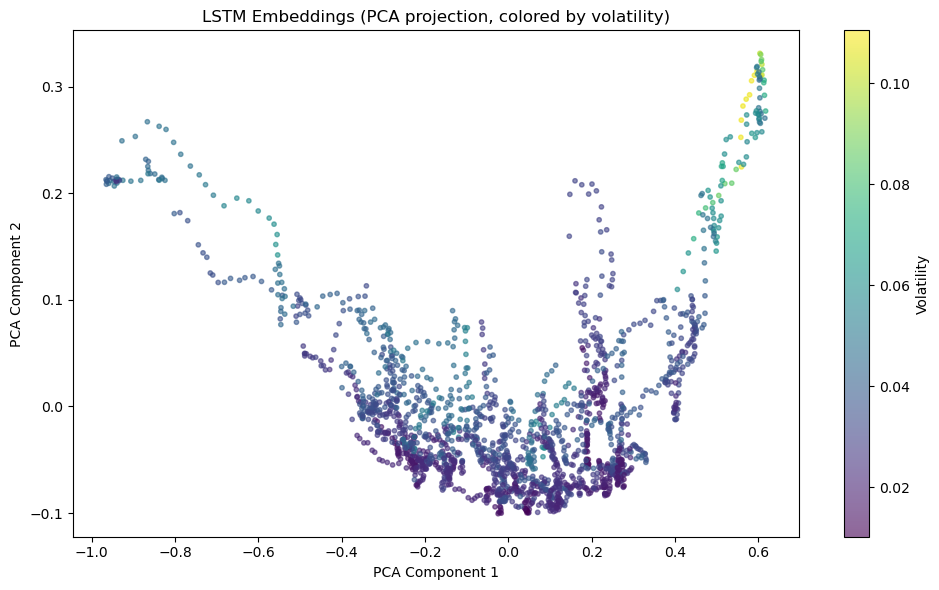

PCA explained variance ratio: [0.9077301  0.07797362]


In [9]:
# ==============================================================================
# Visualize LSTM Embeddings (optional: PCA/t-SNE)
# ==============================================================================
# Quick visualization of embedding distribution

from sklearn.decomposition import PCA

# Reduce 64-dim embeddings to 2D for visualization
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_all)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    embeddings_2d[:, 0], 
    embeddings_2d[:, 1], 
    c=vol_scaler.inverse_transform(y.reshape(-1, 1)).flatten(),
    cmap='viridis',
    alpha=0.6,
    s=10
)
plt.colorbar(scatter, label='Volatility')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('LSTM Embeddings (PCA projection, colored by volatility)')
plt.tight_layout()
plt.show()

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

